In [1]:
import sys
import torch

sys.path.append('..')

from PySESM.models.SESM.SESM import SESM_Model
from PySESM.test_functions.MultivariateNormal import MultivariateNormal
from PySESM.base_functions.Function import GaussianFunctions

In [2]:
n_samples = 1000
n_features = 3
l_functions = 30

In [3]:
mu_1 = torch.tensor([1, 1, 1])
mu_2 = torch.tensor([1, -1, 1])
mu_3 = torch.tensor([-1, -1, -1])
mu_4 = torch.tensor([-1, 1, -1])

sigma_1 = 0.15 * torch.eye(n_features)
sigma_2 = 0.2 * torch.eye(n_features)
sigma_3 = 0.3 * torch.eye(n_features)
sigma_4 = 0.3 * torch.eye(n_features)

means = [mu_1, mu_2, mu_3, mu_4]
covariances = [sigma_1, sigma_2, sigma_3, sigma_4]
scale_factors = [1.0, .5, 1.5, 2.0]

In [4]:
mvn_1 = MultivariateNormal(n_features, means, covariances, scale_factors)

In [5]:
X, y = mvn_1.sample_n(n_samples)

print(X.shape)
print(y.shape)

torch.Size([1000, 3])
torch.Size([1000])


/home/rijegaro/.local/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
gaussian_function = GaussianFunctions(n_features=n_features, n_functions=l_functions)

In [7]:
model = SESM_Model(
    n_samples=n_samples,
    n_features=n_features,
    n_functions=l_functions,
    psi=gaussian_function.gaussian
)

In [8]:
model_epochs = 50
ista_epochs = 100   
dictionary_epochs = 60

ista_alpha = 0.02
ista_lambd = 0.001

dictionary_alpha = 0.02

model.fit(
    X=X,
    y=y,
    model_epochs=model_epochs,
    ista_epochs=ista_epochs,
    ista_alpha=ista_alpha,
    ista_lambd=ista_lambd,
    dictionary_epochs=dictionary_epochs,
    dictionary_alpha=dictionary_alpha
)

Epoch 1 Loss: 2.8156967163085938

Epoch 2 Loss: 0.8360797166824341

Epoch 3 Loss: 0.39007842540740967

Epoch 4 Loss: 0.21261081099510193

Epoch 5 Loss: 0.12590336799621582

Epoch 6 Loss: 0.07931272685527802

Epoch 7 Loss: 0.05280517786741257

Epoch 8 Loss: 0.03726497292518616

Epoch 9 Loss: 0.027858814224600792

Epoch 10 Loss: 0.022019844502210617

Epoch 11 Loss: 0.01831267960369587

Epoch 12 Loss: 0.015878431499004364

Epoch 13 Loss: 0.014214945957064629

Epoch 14 Loss: 0.01303627248853445

Epoch 15 Loss: 0.012172456830739975

Epoch 16 Loss: 0.011498327367007732

Epoch 17 Loss: 0.010945230722427368

Epoch 18 Loss: 0.010474801063537598

Epoch 19 Loss: 0.010062663815915585

Epoch 20 Loss: 0.009692962281405926

Epoch 21 Loss: 0.009355972521007061

Epoch 22 Loss: 0.009045153856277466

Epoch 23 Loss: 0.008756456896662712

Epoch 24 Loss: 0.008486521430313587

Epoch 25 Loss: 0.00823266338557005

Epoch 26 Loss: 0.007992803119122982

Epoch 27 Loss: 0.007765310350805521

Epoch 28 Loss: 0.007548

In [9]:
plot_n_samples = 50

samples = []

for n in range(n_features):
    feature = torch.linspace(-2, 2, plot_n_samples)
    samples.append(feature)

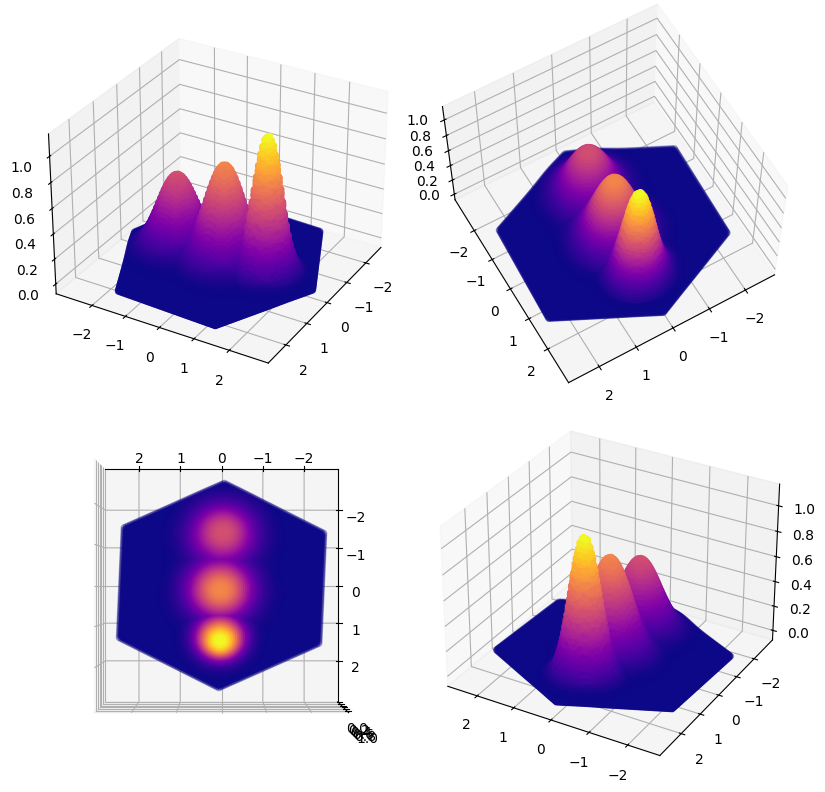

In [10]:
mvn_1.plot(plot_n_samples, samples)

tensor([[-0.0651, -2.6947],
        [-0.0160, -2.6709],
        [ 0.0331, -2.6470],
        ...,
        [-0.0331,  2.6470],
        [ 0.0160,  2.6709],
        [ 0.0651,  2.6948]])


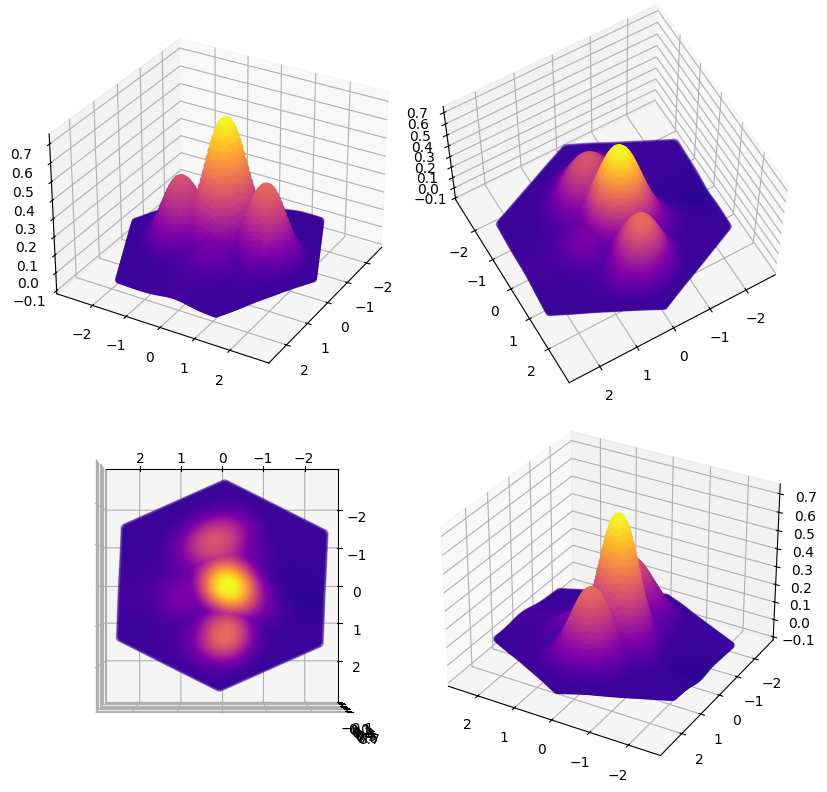

In [11]:
model.plot(plot_n_samples, samples)

In [12]:
print(f'Duración del modelo: {model.time / 60:.2f} minutos')

Duración del modelo: 0.21 minutos


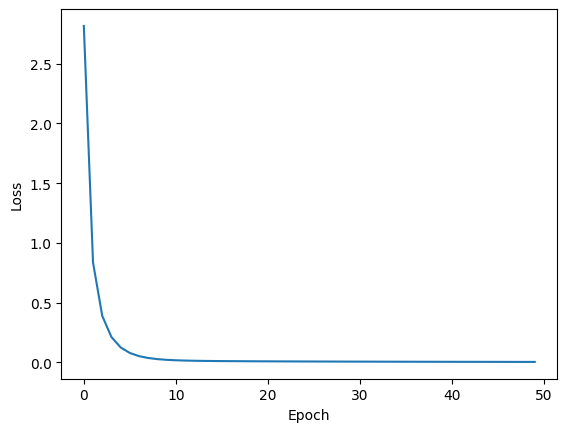

In [13]:
model.plot_loss()